# Importing Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
scaler = StandardScaler()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
Xscaled = scaler.fit_transform(X)

**Elbow Method**

In [8]:
inertia = []
k_values = range(1, 15)
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(Xscaled)
    inertia.append(kmeans.inertia_)

# Visualization

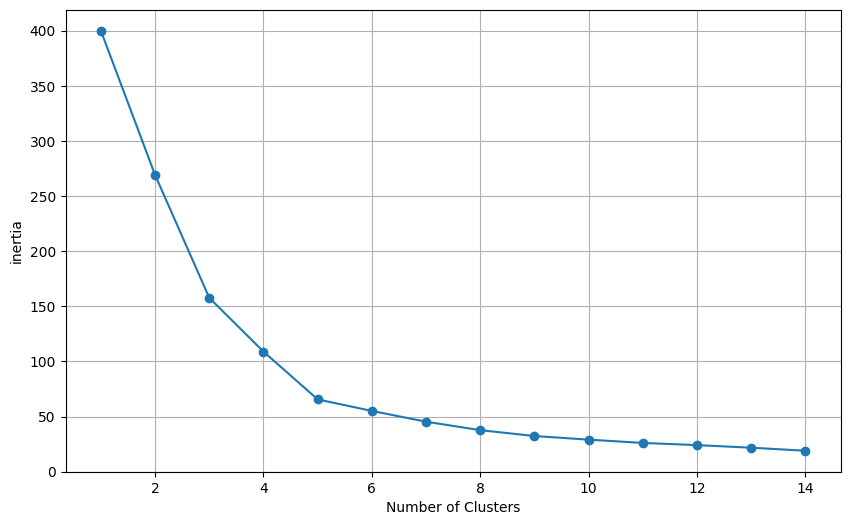

In [9]:
plt.figure(figsize=(10,6))
plt.plot(k_values , inertia , marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('inertia')
plt.grid()
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(Xscaled)

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2


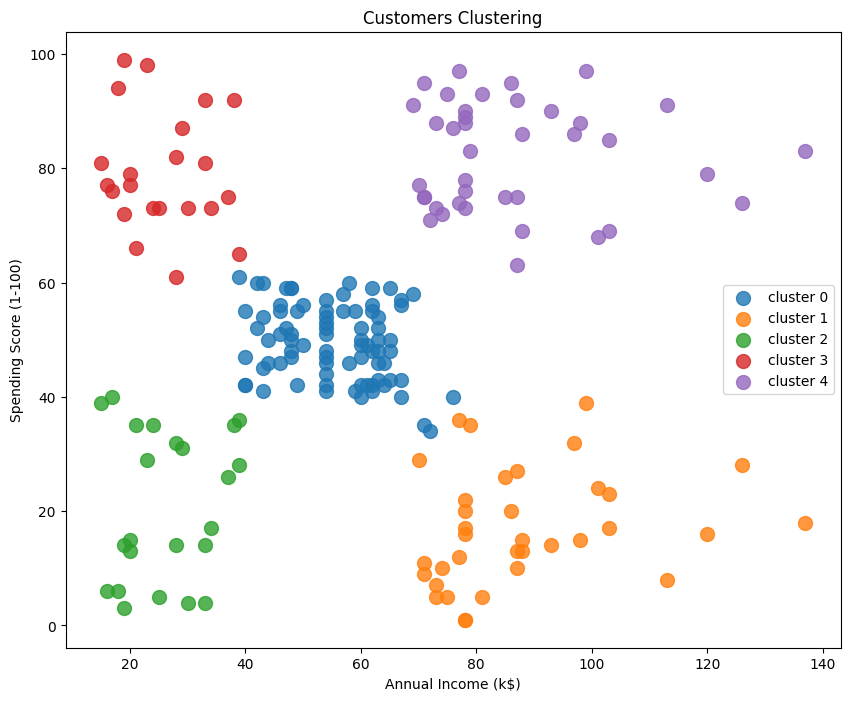

In [12]:
plt.figure(figsize=(10, 8))
for i in range(5):
    data = df[df["cluster"] == i]
    plt.scatter(
        x=data["Annual Income (k$)"], 
        y=data["Spending Score (1-100)"],
        s=100, alpha=0.8, label=f'cluster {i}'
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers Clustering")
plt.legend(loc="center right")
plt.show()

 *  Cluster 1&2: low spenders with low average spending scores 
 *  Cluster 0: medium spenders
* Cluster 3&4: high-value customers with very high spending scores
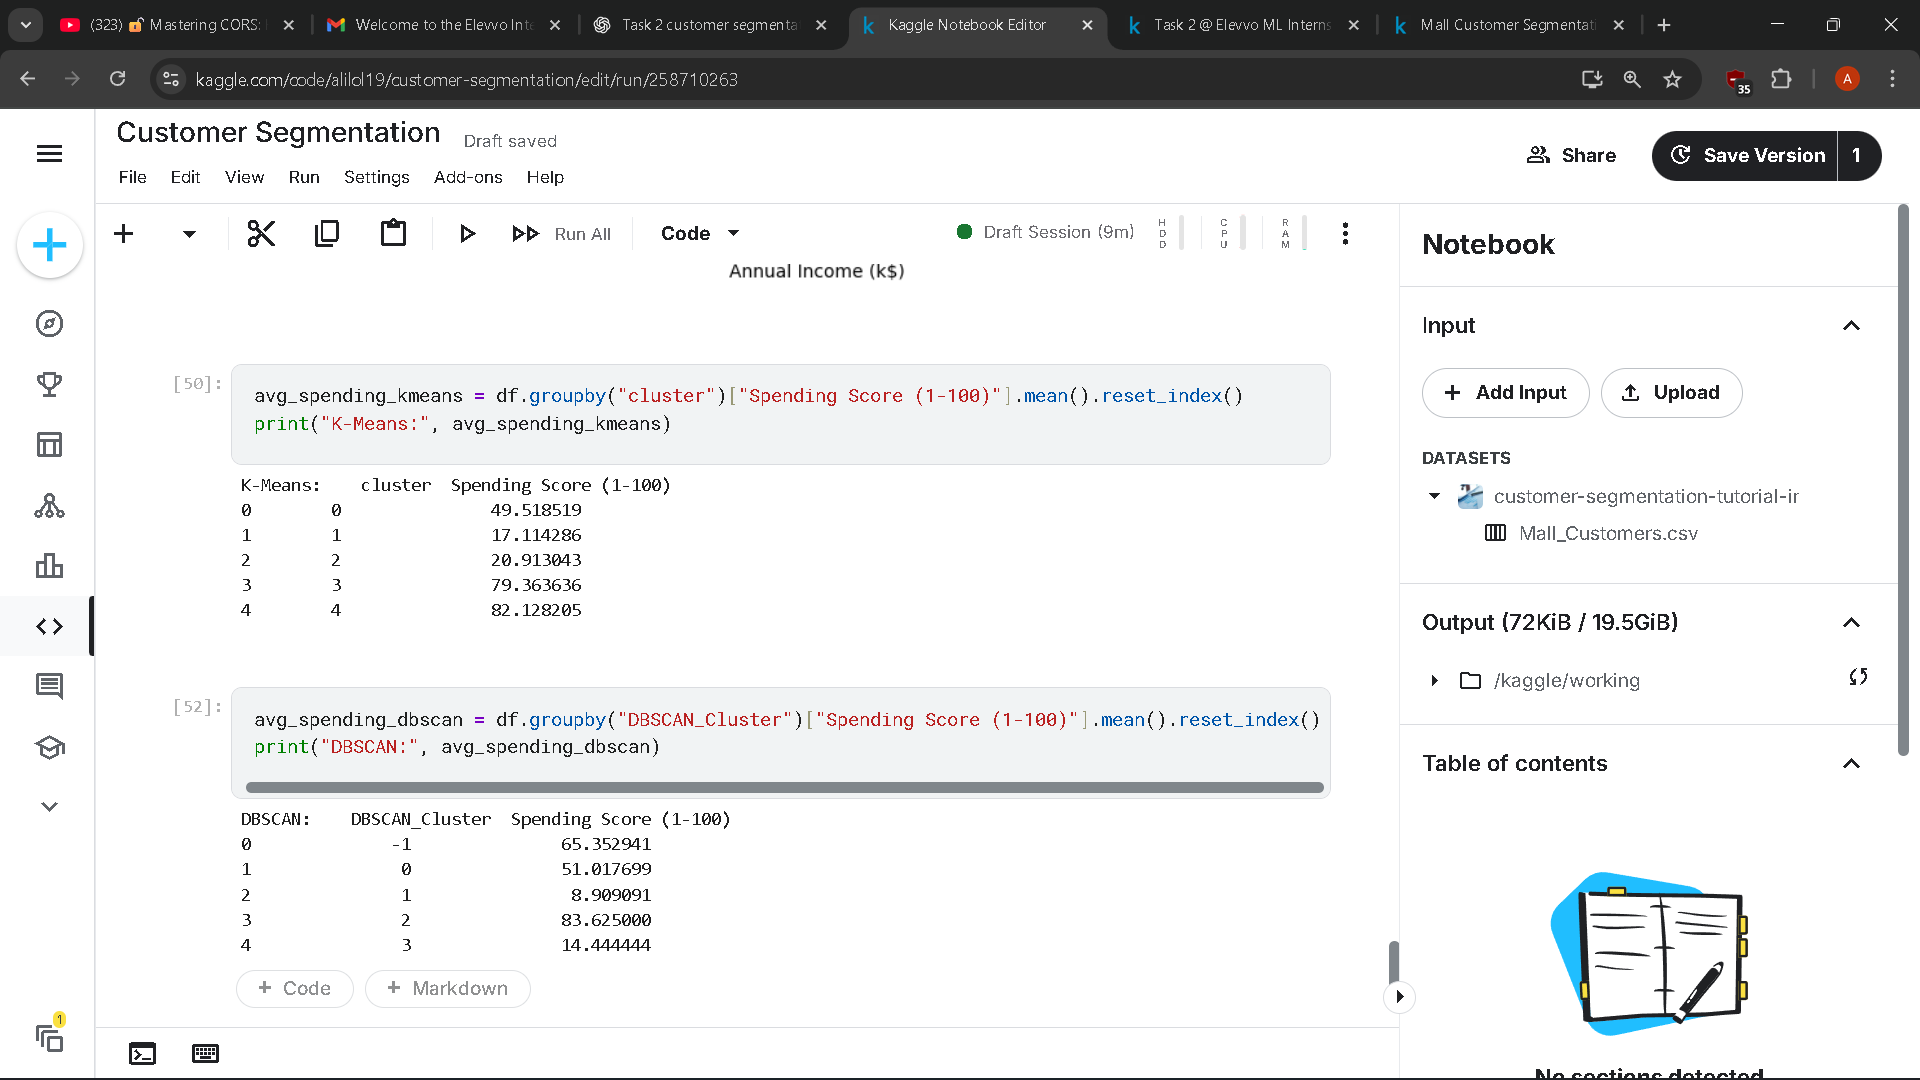

In [13]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
dbscan = DBSCAN(eps=10, min_samples=5)
labels = dbscan.fit_predict(X)

In [14]:
df["DBSCAN_Cluster"] = labels

In [15]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,DBSCAN_Cluster
0,1,Male,19,15,39,2,0
1,2,Male,21,15,81,3,0
2,3,Female,20,16,6,2,1
3,4,Female,23,16,77,3,0
4,5,Female,31,17,40,2,0


# DBSCAN Clustering Visualization

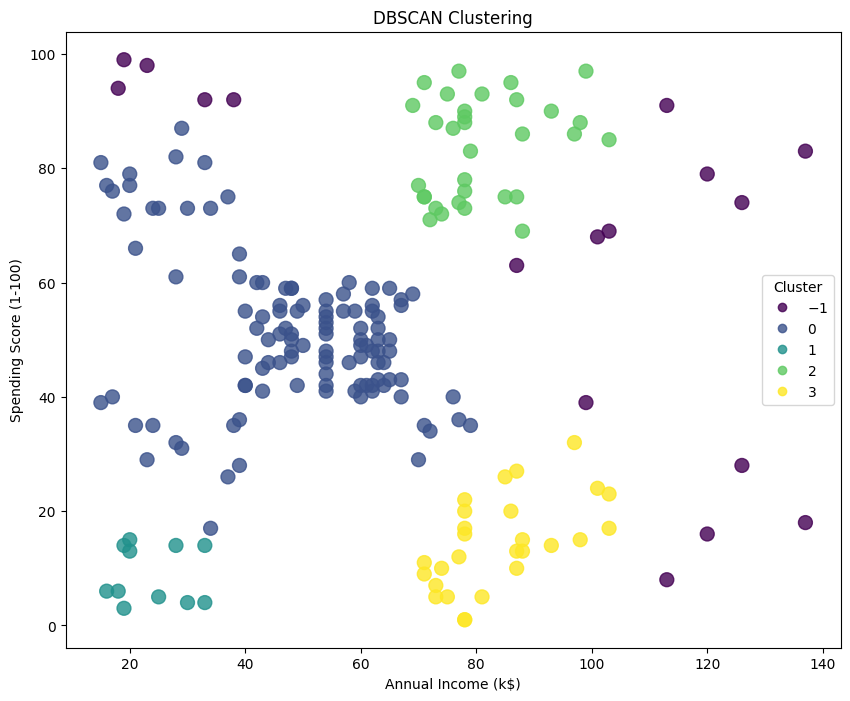

In [16]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["Annual Income (k$)"], df["Spending Score (1-100)"],
    c=df["DBSCAN_Cluster"], cmap="viridis", s=100, alpha=0.8,
    )
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

DBSCAN clustering also provided meaningful groupings but identified some customers as noise (-1),which can be considered outliers.

*K-Means Clustering Results*

In [17]:
avg_spending_kmeans = df.groupby("cluster")["Spending Score (1-100)"].mean().reset_index()
print("K-Means:", avg_spending_kmeans)

K-Means:    cluster  Spending Score (1-100)
0        0               49.518519
1        1               17.114286
2        2               20.913043
3        3               79.363636
4        4               82.128205


*DBSCAN Clustering Results*

In [18]:
avg_spending_dbscan = df.groupby("DBSCAN_Cluster")["Spending Score (1-100)"].mean().reset_index()
print("DBSCAN:", avg_spending_dbscan)

DBSCAN:    DBSCAN_Cluster  Spending Score (1-100)
0              -1               65.352941
1               0               51.017699
2               1                8.909091
3               2               83.625000
4               3               14.444444
